In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("../data/tarkwa_nasa_monthly.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Create lag features — rainfall from previous 1, 2, 3 months
df["lag_1"] = df["rainfall_mm"].shift(1)
df["lag_2"] = df["rainfall_mm"].shift(2)
df["lag_3"] = df["rainfall_mm"].shift(3)

# Drop the first 3 rows which now have NaN lags
df = df.dropna().reset_index(drop=True)

# Full feature set — 6 meteorological predictors + seasonality + trend + lags
feature_cols = [
    "temp_mean_C", "temp_max_C", "temp_min_C",
    "humidity_pct", "pressure_kPa", "wind_speed_ms",
    "month", "year", "lag_1", "lag_2", "lag_3"
]

X = df[feature_cols].values
y = df["rainfall_mm"].values

# Date-based 80/20 split
split_date = "2019-01-01"
split_idx = df[df["date"] >= split_date].index[0]

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Total rows after lag drop: {len(df)}")
print(f"Train: {len(X_train)} rows, ending {df['date'].iloc[split_idx-1].date()}")
print(f"Test:  {len(X_test)} rows, starting {df['date'].iloc[split_idx].date()}")
print(f"Features: {feature_cols}")

Total rows after lag drop: 435
Train: 345 rows, ending 2018-12-01
Test:  90 rows, starting 2019-01-01
Features: ['temp_mean_C', 'temp_max_C', 'temp_min_C', 'humidity_pct', 'pressure_kPa', 'wind_speed_ms', 'month', 'year', 'lag_1', 'lag_2', 'lag_3']


XGBoost (NASA POWER) Test Set Performance:
  RMSE: 68.78
  MAE:  50.84
  MAPE: 32.15%
  R²:   0.6608

Feature importances:
  month: 0.258
  humidity_pct: 0.246
  temp_max_C: 0.136
  temp_min_C: 0.084
  lag_2: 0.071
  wind_speed_ms: 0.058
  lag_3: 0.046
  pressure_kPa: 0.041
  year: 0.022
  lag_1: 0.019
  temp_mean_C: 0.018


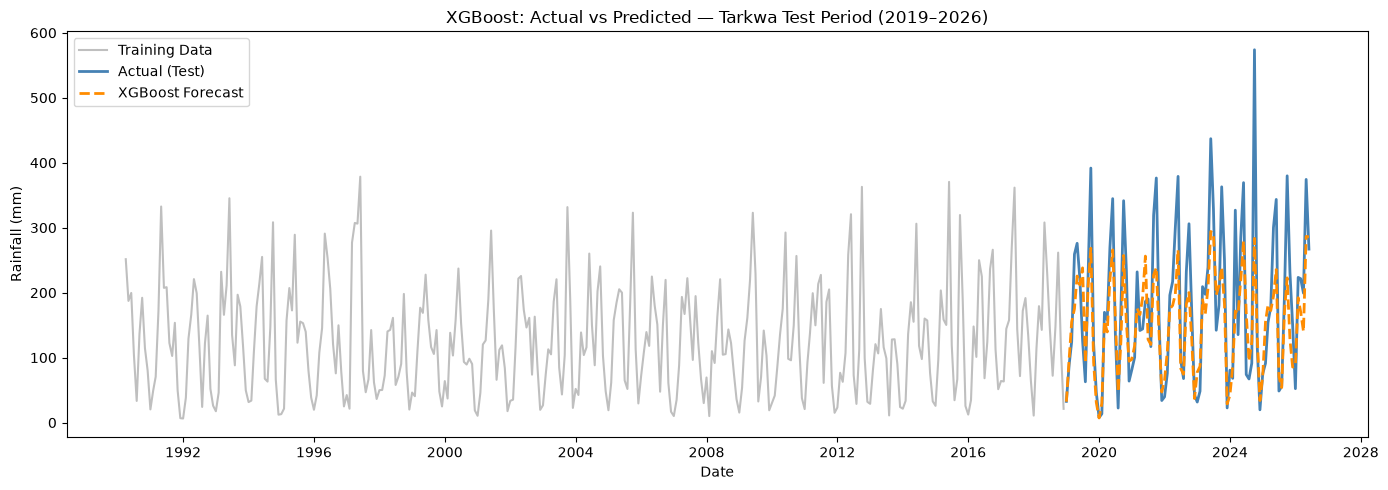

In [2]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print("XGBoost (NASA POWER) Test Set Performance:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")

print("\nFeature importances:")
for feat, imp in sorted(zip(feature_cols, xgb_model.feature_importances_),
                         key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {imp:.3f}")

# Plot actual vs predicted
test_dates = df["date"].iloc[split_idx:].reset_index(drop=True)
train_dates = df["date"].iloc[:split_idx].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(train_dates, y_train, label="Training Data", color="gray", alpha=0.5)
plt.plot(test_dates, y_test, label="Actual (Test)", color="steelblue", linewidth=2)
plt.plot(test_dates, y_pred, label="XGBoost Forecast", color="darkorange", linewidth=2, linestyle="--")
plt.title("XGBoost: Actual vs Predicted — Tarkwa Test Period (2019–2026)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/nasa_xgboost_actual_vs_predicted.png", dpi=150)
plt.show()

In [3]:
import joblib

MODEL_PATH = "../models/nasa_xgboost_model.pkl"
joblib.dump(xgb_model, MODEL_PATH)

# Reload check
loaded = joblib.load(MODEL_PATH)
test_pred = loaded.predict(X_test[:3])
print(f"Model saved to {MODEL_PATH}")
print(f"Reload check — first 3 predictions: {test_pred.round(1)}")

Model saved to ../models/nasa_xgboost_model.pkl
Reload check — first 3 predictions: [ 32.2  98.3 155. ]
